# 🤖 Etapa 3 – Modelagem de Machine Learning
Notebook: `03_Modelagem.ipynb`

Dataset de entrada: `../data/students_clean.csv`


## 1. Importação e Carregamento dos Dados

In [49]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

data_path = '../../data/save/students_clean.csv'
df = pd.read_csv(data_path)
df.head()


,age,study_hours_week,attendance_rate,sleep_hours,previous_scores,final_grade,student_id_STD00002,student_id_STD00003,student_id_STD00004,student_id_STD00005,...,health_status_ Good,health_status_ Poor,health_status_EXCELLENT,health_status_Excellent,health_status_GOOD,health_status_Good,health_status_POOR,health_status_Poor,study_total,grade_ratio
0,0.224769,-0.769824,0.974492,-0.294650,-0.850525,-0.899949,False,False,False,False,...,False,False,False,False,False,True,False,False,-0.782596,0.449496
1,-1.111785,0.657444,-0.087126,0.877922,-0.755216,0.851574,False,False,False,False,...,False,False,False,False,False,True,False,False,0.739970,-0.613513
2,1.360545,0.239021,0.001919,-0.205237,1.557113,1.062455,False,False,False,False,...,False,False,False,False,False,True,False,False,0.220168,-0.202681
3,-0.195364,-1.343025,0.853786,0.098423,-0.685901,-0.703843,False,False,False,False,...,False,False,False,True,False,False,False,False,-1.308255,0.962550
4,-1.111785,-1.217720,-0.916237,0.839793,-0.353402,-1.187392,False,False,False,False,...,False,False,False,True,False,False,False,False,-1.111173,0.747373


CORRIGE 2 NaN que retorna padrão da ETAPA 2

In [50]:
# Substituir NaN pela mediana da própria coluna
df['grade_ratio'] = df['grade_ratio'].fillna(df['grade_ratio'].median())
df['study_hours_week'] = df['study_hours_week'].fillna(df['study_hours_week'].median())

# conferir se resolveu
df[['grade_ratio', 'study_hours_week']].isna().sum()


grade_ratio         0
study_hours_week    0
dtype: int64

### Definição do target

**Ajuste esta variável se o nome da coluna alvo for diferente.**

In [51]:
TARGET_COL = 'final_grade'

if TARGET_COL not in df.columns:
    raise ValueError(f'Coluna alvo {TARGET_COL!r} não encontrada.')

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X.shape, X_train.shape, X_test.shape


((2510, 2567), (2008, 2567), (502, 2567))

## 2. Métricas de Regressão

In [52]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

# baseline bobo usando média
y_pred_mean = np.full_like(y_test, y_train.mean(), dtype=float)
regression_metrics(y_test, y_pred_mean)


{'MAE': 0.8082238119033363,
 'MSE': 0.9135501053562158,
 'RMSE': np.float64(0.9557981509483139),
 'R2': -0.005640480720345176,
 'MAPE': np.float64(100.86054435407085)}

## 3. Baseline – Regressão Linear

In [53]:
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)
metrics_baseline = regression_metrics(y_test, y_pred_baseline)
metrics_baseline


{'MAE': 0.4382748895915598,
 'MSE': 0.3331920367493867,
 'RMSE': np.float64(0.5772278897882419),
 'R2': 0.6332205556714467,
 'MAPE': np.float64(146.49715804874262)}

## 4. Modelos Avançados

In [54]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Lasso': Lasso(alpha=0.001, random_state=42),
    'ElasticNet': ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
    'SVR': SVR(kernel='rbf'),
    'KNN': KNeighborsRegressor(n_neighbors=5)
}

models


{'LinearRegression': LinearRegression(),
 'Ridge': Ridge(random_state=42),
 'Lasso': Lasso(alpha=0.001, random_state=42),
 'ElasticNet': ElasticNet(alpha=0.001, random_state=42),
 'DecisionTree': DecisionTreeRegressor(random_state=42),
 'RandomForest': RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42),
 'GradientBoosting': GradientBoostingRegressor(random_state=42),
 'SVR': SVR(),
 'KNN': KNeighborsRegressor()}

## 5. Validação Cruzada (5-fold)

In [55]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    mae_scores = -cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_error')
    rmse_scores = -cross_val_score(model, X, y, cv=cv, scoring='neg_root_mean_squared_error')
    r2_scores = cross_val_score(model, X, y, cv=cv, scoring='r2')

    results.append({
        'Modelo': name,
        'MAE_cv_mean': mae_scores.mean(),
        'RMSE_cv_mean': rmse_scores.mean(),
        'R2_cv_mean': r2_scores.mean()
    })

results_df = pd.DataFrame(results).sort_values('RMSE_cv_mean')
results_df


,Modelo,MAE_cv_mean,RMSE_cv_mean,R2_cv_mean
7,SVR,0.374168,0.509987,0.739022
6,GradientBoosting,0.391014,0.522060,0.726491
5,RandomForest,0.419828,0.572649,0.671098
3,ElasticNet,0.426860,0.588171,0.651916
2,Lasso,0.426789,0.588500,0.651520
1,Ridge,0.434867,0.588571,0.651577
0,LinearRegression,0.435163,0.588664,0.651491
8,KNN,0.485788,0.639431,0.589164
4,DecisionTree,0.553844,0.785816,0.378298


## 6. Avaliação em Teste

In [56]:
test_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    m = regression_metrics(y_test, y_pred)
    m['Modelo'] = name
    test_results.append(m)

test_results_df = pd.DataFrame(test_results).set_index('Modelo')
test_results_df.sort_values('RMSE')


,MAE,MSE,RMSE,R2,MAPE
Modelo,,,,,
SVR,0.358019,0.237487,0.487326,0.738573,126.083860
GradientBoosting,0.384700,0.261749,0.511614,0.711865,117.877489
RandomForest,0.411403,0.306651,0.553761,0.662437,127.121859
ElasticNet,0.430569,0.332505,0.576633,0.633976,144.512169
Lasso,0.429786,0.332523,0.576648,0.633958,144.647100
LinearRegression,0.438275,0.333192,0.577228,0.633221,146.497158
Ridge,0.439205,0.334635,0.578477,0.631632,145.973061
KNN,0.495834,0.425844,0.652567,0.531229,145.267153
DecisionTree,0.563250,0.639410,0.799631,0.296134,180.391035


## 7. Comparação Visual

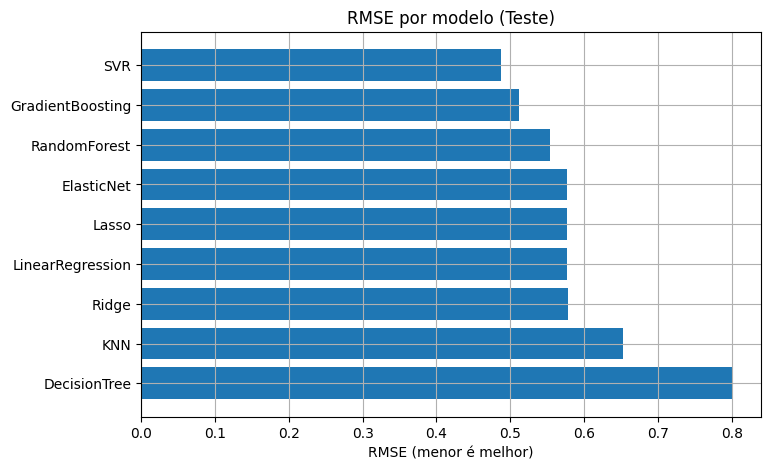

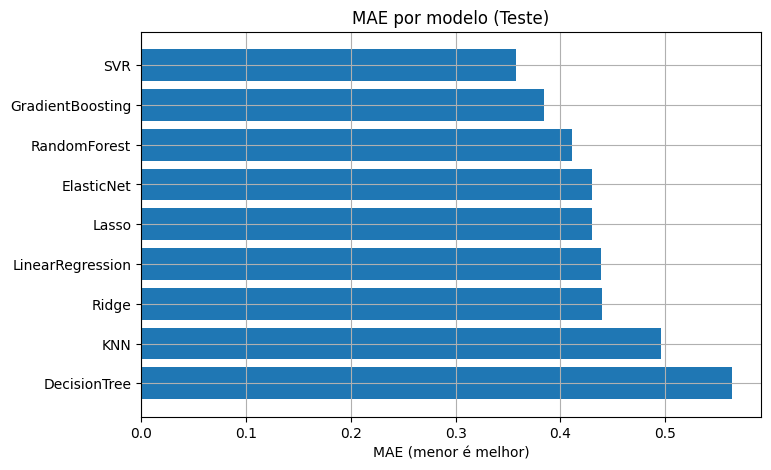

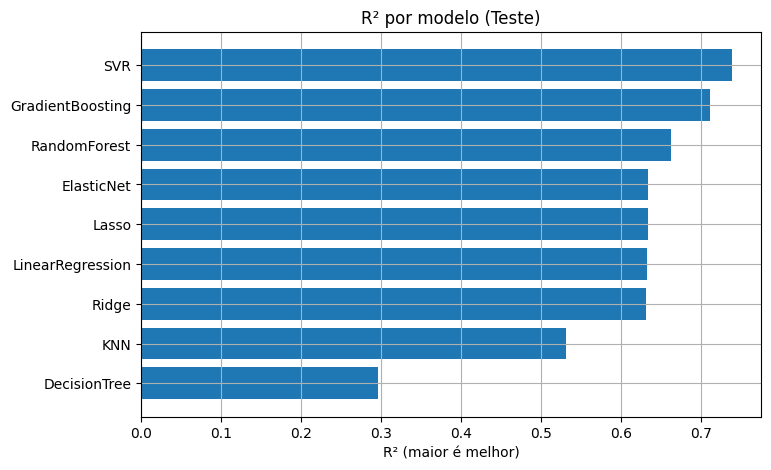

In [57]:
ordered = test_results_df.sort_values('RMSE')

plt.figure(figsize=(8,5))
plt.barh(ordered.index, ordered['RMSE'])
plt.xlabel('RMSE (menor é melhor)')
plt.title('RMSE por modelo (Teste)')
plt.gca().invert_yaxis()
plt.show()

plt.figure(figsize=(8,5))
plt.barh(ordered.index, ordered['MAE'])
plt.xlabel('MAE (menor é melhor)')
plt.title('MAE por modelo (Teste)')
plt.gca().invert_yaxis()
plt.show()

plt.figure(figsize=(8,5))
plt.barh(ordered.index, ordered['R2'])
plt.xlabel('R² (maior é melhor)')
plt.title('R² por modelo (Teste)')
plt.gca().invert_yaxis()
plt.show()


## 8. Melhor Modelo e Análise de Erros

In [58]:
best_name = test_results_df['RMSE'].idxmin()
best_name, test_results_df.loc[best_name]


('SVR',
 MAE       0.358019
 MSE       0.237487
 RMSE      0.487326
 R2        0.738573
 MAPE    126.083860
 Name: SVR, dtype: float64)

In [59]:
best_model = models[best_name]
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)
best_metrics = regression_metrics(y_test, y_pred_best)
best_metrics


{'MAE': 0.35801852178786897,
 'MSE': 0.2374869368264355,
 'RMSE': np.float64(0.48732631452286207),
 'R2': 0.7385732036867156,
 'MAPE': np.float64(126.08385988163036)}

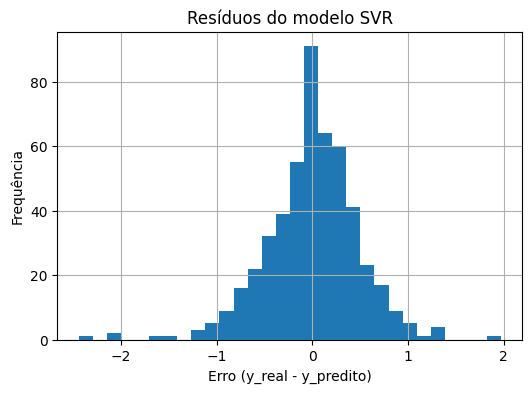

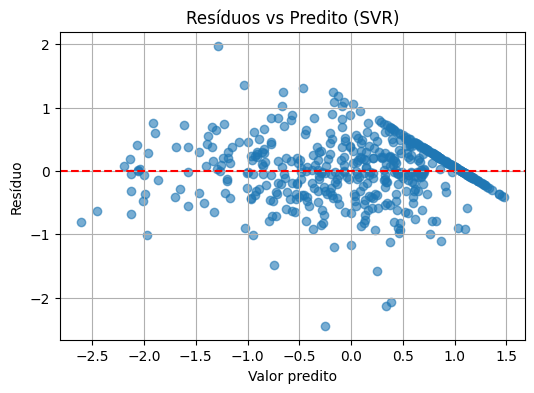

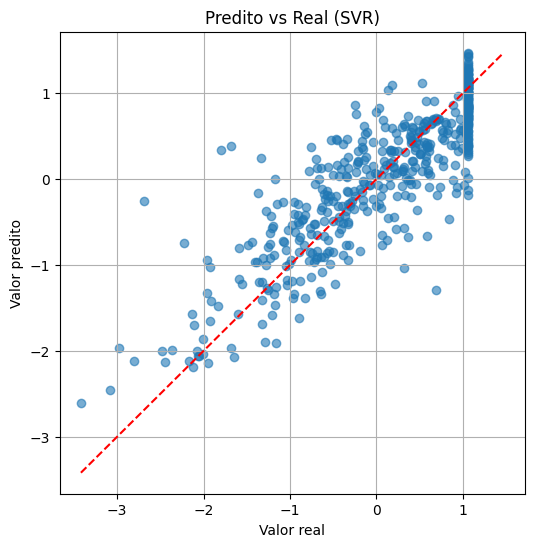

In [60]:
residuals = y_test - y_pred_best

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30)
plt.title(f'Resíduos do modelo {best_name}')
plt.xlabel('Erro (y_real - y_predito)')
plt.ylabel('Frequência')
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(y_pred_best, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title(f'Resíduos vs Predito ({best_name})')
plt.xlabel('Valor predito')
plt.ylabel('Resíduo')
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_best, alpha=0.6)
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.xlabel('Valor real')
plt.ylabel('Valor predito')
plt.title(f'Predito vs Real ({best_name})')
plt.show()


## 9. Importância de Features (se disponível)

In [61]:
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    fi_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}) 
    fi_df = fi_df.sort_values('Importance', ascending=False).head(15)

    display(fi_df)
    plt.figure(figsize=(8,5))
    plt.barh(fi_df['Feature'], fi_df['Importance'])
    plt.gca().invert_yaxis()
    plt.title(f'Importância das Features - Top 15 ({best_name})')
    plt.xlabel('Importance')
    plt.show()
else:
    print(f'O modelo {best_name} não possui atributo feature_importances_.')


O modelo SVR não possui atributo feature_importances_.


## 10. Conclusão

- Testamos vários modelos de regressão (Linear, Ridge, Lasso, ElasticNet, Tree, Random Forest, Gradient Boosting, SVR, KNN).
- Usamos validação cruzada (5-fold) para estimar desempenho médio.
- Avaliamos todos no conjunto de teste com MAE, RMSE e R².
- Selecionamos o melhor modelo com base no menor RMSE no teste.
- Fizemos análise gráfica dos erros e, quando possível, importância de features.

Este notebook está pronto para ser usado na apresentação da Etapa 3.